In [ ]:
from google.colab import userdata
from huggingface_hub import login
# No Hugging Face authentication is required for the public WavLM checkpoint, but useful
login(token=userdata.get('HF_TOKEN'))

In [ ]:
import kagglehub
path = kagglehub.dataset_download("aniket202411001/asvspoof5-flac")
print("Path to dataset files:", path)

100%|██████████| 20.8G/20.8G [02:12<00:00, 168MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aniket202411001/asvspoof5-flac/versions/1


In [ ]:
import kagglehub
path_2019 = kagglehub.dataset_download("awsaf49/asvpoof-2019-dataset")
print(path_2019)

100%|██████████| 23.6G/23.6G [02:25<00:00, 173MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1


In [ ]:
from pathlib import Path

# Root path from kagglehub
path_2019 = Path(path_2019)

# Directly point to LA
base = path_2019 / "LA"/"LA"

# Protocol directory
proto_dir = base / "ASVspoof2019_LA_cm_protocols"
print("Protocol files:")
for item in proto_dir.iterdir():
    print(f" {item.name}")

# Train directory
train_dir = base / "ASVspoof2019_LA_train"
print("\nTrain directory contents:")
for item in train_dir.iterdir():
    print(f" {item.name}")

Protocol files:
 ASVspoof2019.LA.cm.eval.trl.txt
 ASVspoof2019.LA.cm.dev.trl.txt
 ASVspoof2019.LA.cm.train.trn.txt

Train directory contents:
 LICENSE.txt
 flac


In [ ]:
# Paths for 2019 LA

train_2019_audio = base / "ASVspoof2019_LA_train" / "flac"
train_2019_proto = base / "ASVspoof2019_LA_cm_protocols" / "ASVspoof2019.LA.cm.train.trn.txt"

dev_2019_audio = base / "ASVspoof2019_LA_dev" / "flac"
dev_2019_proto = base / "ASVspoof2019_LA_cm_protocols" / "ASVspoof2019.LA.cm.dev.trl.txt"

# Verify files exist
print(f"Train audio exists: {train_2019_audio.exists()}")
print(f"Train proto exists: {train_2019_proto.exists()}")
print(f"Dev audio exists: {dev_2019_audio.exists()}")

# Check sample count
train_files = list(train_2019_audio.glob("*.flac"))
print(f"Train audio files: {len(train_files)}")

Train audio exists: True
Train proto exists: True
Dev audio exists: True
Train audio files: 25380


In [ ]:
import torch
import librosa
import random
import numpy as np
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

def rawboost_augment(x, sr=16000):
    choice = np.random.randint(0, 3)
    if choice == 0:
        N_f = 5
        freqs = np.random.randint(0, sr//2, N_f)
        alpha = np.random.uniform(0.1, 0.3)
        noise = np.zeros(len(x))
        for f in freqs:
            t = np.arange(len(x)) / sr
            noise += np.sin(2 * np.pi * f * t)
        noise = noise / (noise.std() + 1e-8) * x.std() * alpha
        return x + noise
    elif choice == 1:
        alpha = np.random.uniform(0.05, 0.2)
        impulse_idx = np.random.choice(len(x),
                      size=int(len(x)*0.01), replace=False)
        x_aug = x.copy()
        x_aug[impulse_idx] += np.random.randn(len(impulse_idx)) * x.std() * alpha
        return x_aug
    else:
        alpha = np.random.uniform(0.01, 0.1)
        noise = np.random.randn(len(x)) * x.std() * alpha
        return x + noise

# ASVSpoof5 dataset class — folder based (bonafide/ and spoof/)
class ASVDataset(Dataset):
    def __init__(self, root_dir, feature_extractor,
                 duration=4.0, sr=16000,
                 balance=False, augment=False):
        self.root_dir = Path(root_dir)
        self.feature_extractor = feature_extractor
        self.duration = duration
        self.sr = sr
        self.augment = augment

        bonafide, spoof = [], []
        for label_idx, label_name in enumerate(['bonafide', 'spoof']):
            folder = self.root_dir / label_name
            for file_path in folder.glob('*.flac'):
                if label_idx == 0:
                    bonafide.append((file_path, 0))
                else:
                    spoof.append((file_path, 1))

        print(f"ASV5 {root_dir} — Bonafide: {len(bonafide)}, Spoof: {len(spoof)}")

        if balance:
            min_count = min(len(bonafide), len(spoof))
            bonafide = random.sample(bonafide, min_count)
            spoof = random.sample(spoof, min_count)
            print(f"Balanced: {min_count} each")

        self.samples = bonafide + spoof
        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        audio, _ = librosa.load(str(file_path),
                                 sr=self.sr, duration=self.duration)
        target_length = int(self.sr * self.duration)
        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)))
        else:
            audio = audio[:target_length]

        if self.augment and np.random.random() > 0.5:
            audio = rawboost_augment(audio, self.sr)

        inputs = self.feature_extractor(
            audio, sampling_rate=self.sr,
            return_tensors="pt", padding=True
        )
        return {
            "input_values": inputs.input_values.squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

# ASVSpoof2019 dataset class — protocol file based
class ASV2019Dataset(Dataset):
    def __init__(self, audio_dir, protocol_file,
                 feature_extractor, duration=4.0,
                 sr=16000, balance=False, augment=False):
        self.audio_dir = Path(audio_dir)
        self.feature_extractor = feature_extractor
        self.duration = duration
        self.sr = sr
        self.augment = augment

        bonafide, spoof = [], []
        with open(protocol_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                filename = parts[1]
                label = parts[4]
                fpath = self.audio_dir / f"{filename}.flac"
                if fpath.exists():
                    if label == 'bonafide':
                        bonafide.append((fpath, 0))
                    else:
                        spoof.append((fpath, 1))

        print(f"ASV2019 — Bonafide: {len(bonafide)}, Spoof: {len(spoof)}")

        if balance:
            min_count = min(len(bonafide), len(spoof))
            bonafide = random.sample(bonafide, min_count)
            spoof = random.sample(spoof, min_count)
            print(f"Balanced: {min_count} each")

        self.samples = bonafide + spoof
        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        audio, _ = librosa.load(str(file_path),
                                 sr=self.sr, duration=self.duration)
        target_length = int(self.sr * self.duration)
        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)))
        else:
            audio = audio[:target_length]

        if self.augment and np.random.random() > 0.5:
            audio = rawboost_augment(audio, self.sr)

        inputs = self.feature_extractor(
            audio, sampling_rate=self.sr,
            return_tensors="pt", padding=True
        )
        return {
            "input_values": inputs.input_values.squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [ ]:
import os
from transformers import WavLMForSequenceClassification, AutoFeatureExtractor
from torch.utils.data import ConcatDataset

feature_extractor = AutoFeatureExtractor.from_pretrained("microsoft/wavlm-large") #walm-large
model = WavLMForSequenceClassification.from_pretrained(
    "microsoft/wavlm-large",
    num_labels=2,
    ignore_mismatched_sizes=True
)
# Freeze all WavLM layers
for param in model.wavlm.parameters():
    param.requires_grad = False

# Unfreeze last 5 transformer layers
for layer in model.wavlm.encoder.layers[-5:]:
    for param in layer.parameters():
        param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

# ASVSpoof5 paths
train_path = os.path.join(path, "ASV_Main/train")
val_path = os.path.join(path, "ASV_Main/val")
test_path = os.path.join(path, "ASV_Main/test")

# ASVSpoof2019 paths
base_2019 = Path(path_2019) / "LA" / "LA"
train_2019_audio = base_2019 / "ASVspoof2019_LA_train" / "flac"
train_2019_proto = base_2019 / "ASVspoof2019_LA_cm_protocols" / "ASVspoof2019.LA.cm.train.trn.txt"
dev_2019_audio = base_2019 / "ASVspoof2019_LA_dev" / "flac"
dev_2019_proto = base_2019 / "ASVspoof2019_LA_cm_protocols" / "ASVspoof2019.LA.cm.dev.trl.txt"

# Initialize all datasets
train_2019 = ASV2019Dataset(
    audio_dir=train_2019_audio,
    protocol_file=train_2019_proto,
    feature_extractor=feature_extractor,
    balance=True, augment=True
)
dev_2019 = ASV2019Dataset(
    audio_dir=dev_2019_audio,
    protocol_file=dev_2019_proto,
    feature_extractor=feature_extractor,
    balance=True, augment=True
)
train_ds = ASVDataset(train_path, feature_extractor, balance=True, augment=True)
val_ds_as_train = ASVDataset(val_path, feature_extractor, balance=True, augment=True)

combined_train_ds = ConcatDataset([train_2019, dev_2019, train_ds, val_ds_as_train])
test_ds = ASVDataset(test_path, feature_extractor, balance=False, augment=False)

print(f"Combined train: {len(combined_train_ds)}")
print(f"Test: {len(test_ds)}")

preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

WavLMForSequenceClassification LOAD REPORT from: microsoft/wavlm-large
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 
projector.bias    | MISSING | 
projector.weight  | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable: 63,246,714 / 315,716,034 (20.0%)
ASV2019 — Bonafide: 2580, Spoof: 22800
Balanced: 2580 each
ASV2019 — Bonafide: 2548, Spoof: 22296
Balanced: 2548 each
ASV5 /root/.cache/kagglehub/datasets/aniket202411001/asvspoof5-flac/versions/1/ASV_Main/train — Bonafide: 3742, Spoof: 32758
Balanced: 3742 each
ASV5 /root/.cache/kagglehub/datasets/aniket202411001/asvspoof5-flac/versions/1/ASV_Main/val — Bonafide: 10210, Spoof: 35940
Balanced: 10210 each
ASV5 /root/.cache/kagglehub/datasets/aniket202411001/asvspoof5-flac/versions/1/ASV_Main/test — Bonafide: 13865, Spoof: 54323
Combined train: 38160
Test: 68188


In [ ]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve

def compute_eer(labels, scores): #eer(equal error rate)
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    eer_idx = np.argmin(np.abs(fpr - fnr))
    return float((fpr[eer_idx] + fnr[eer_idx]) / 2)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    scores = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    acc = (predictions == labels).mean()
    f1 = f1_score(labels, predictions, average='binary')
    precision = precision_score(labels, predictions)
    recall = recall_score(labels, predictions)
    eer = compute_eer(labels, scores)
    return {
        "accuracy": float((predictions == labels).mean()),
        "f1": f1_score(labels, predictions, average='binary'),
        "precision": precision_score(labels, predictions),
        "recall": recall_score(labels, predictions),
        "eer": compute_eer(labels, scores)
    }

In [ ]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="./artifacts/asv_wavlm_large_v2_final",
    num_train_epochs=15,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=1000,
    weight_decay=0.01,
    learning_rate=5e-5,
    logging_steps=200,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eer",
    greater_is_better=False,
    fp16=True,
    remove_unused_columns=False,
    report_to="none",
    gradient_accumulation_steps=1,
    dataloader_num_workers=4,
    save_total_limit=3
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=combined_train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Starting WavLM Fine-tuning...")
trainer.train()

FINAL_MODEL_DIR = "./artifacts/asv_wavlm_large_v2_final_model"
trainer.save_model(FINAL_MODEL_DIR)
feature_extractor.save_pretrained(FINAL_MODEL_DIR)

print("Done!")

In [ ]:
print("Train 2019:", len(train_2019))
print("Dev 2019:", len(dev_2019))
print("Train DS:", len(train_ds))
print("Val DS:", len(val_ds_as_train))
print("Combined:", len(combined_train_ds))
print("Test:", len(test_ds))

Train 2019: 5160
Dev 2019: 5096
Train DS: 7484
Val DS: 20420
Combined: 38160
Test: 68188


In [ ]:
import torch
import librosa
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from transformers import AutoFeatureExtractor, WavLMForSequenceClassification

# Load your saved model
model_path = "./model_checkpoint"  # Fine-tuned checkpoint not included in repository
feature_extractor = AutoFeatureExtractor.from_pretrained("microsoft/wavlm-base")
model = WavLMForSequenceClassification.from_pretrained(model_path)
model.eval()

def predict_with_explanation(audio_path, sr=16000, duration=4.0):
    # Load audio
    audio, _ = librosa.load(audio_path, sr=sr, duration=duration)
    target_length = int(sr * duration)
    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)))
    else:
        audio = audio[:target_length]

    # Get model inputs
    inputs = feature_extractor(audio, sampling_rate=sr, return_tensors="pt", padding=True)
    input_values = inputs.input_values
    # Hook to capture gradients and activations from last transformer layer
    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0].detach())

    def forward_hook(module, input, output):
        activations.append(output[0].detach())

    # Attach hooks to last WavLM transformer layer
    target_layer = model.wavlm.encoder.layers[-1]
    fwd_handle = target_layer.register_forward_hook(forward_hook)
    bwd_handle = target_layer.register_full_backward_hook(backward_hook)

    # Forward pass
    input_values.requires_grad = True
    outputs = model(input_values)
    logits = outputs.logits

    # Get prediction
    probs = torch.softmax(logits, dim=-1)
    pred_class = torch.argmax(probs, dim=-1).item()
    confidence = probs[0][pred_class].item()

    # Backward pass on predicted class
    model.zero_grad()
    logits[0][pred_class].backward()

    # Remove hooks
    fwd_handle.remove()
    bwd_handle.remove()

    # Compute Grad-CAM: weight activations by gradients
    grad = gradients[0]        # shape: [1, time_steps, hidden_size]
    act = activations[0]       # shape: [1, time_steps, hidden_size]

    weights = grad.mean(dim=-1, keepdim=True)   # average over hidden dim
    cam = (weights * act).sum(dim=-1)            # weighted sum
    cam = torch.relu(cam).squeeze().numpy()      # keep positive activations only

    # Normalize to 0-1
    if cam.max() > 0:
        cam = (cam - cam.min()) / (cam.max() - cam.min())

    return audio, cam, pred_class, confidence, probs

preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/492 [00:00<?, ?it/s]

In [ ]:
eval_2019_audio = base_2019 / "ASVspoof2019_LA_eval" / "flac"
eval_proto = base_2019 / "ASVspoof2019_LA_cm_protocols" / "ASVspoof2019.LA.cm.eval.trl.txt"
eval_files = list(eval_2019_audio.glob("*.flac"))
print(f"Eval audio files found: {len(eval_files)}")
# Check protocol
with open(eval_proto) as f:
    lines = f.readlines()
print(f"Protocol lines: {len(lines)}")
print(f"Sample line: {lines[0]}")

Eval audio files found: 71933
Protocol lines: 71237
Sample line: LA_0039 LA_E_2834763 - A11 spoof



In [ ]:
from collections import defaultdict
import random

attack_results = defaultdict(lambda: {"correct": 0, "total": 0, "cams": []})
samples_by_attack = defaultdict(list)

with open(eval_proto) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        filename = parts[1]
        attack = parts[3]
        label = parts[4]
        fpath = eval_2019_audio / f"{filename}.flac"  # fixed path
        if fpath.exists() and label == 'spoof':
            samples_by_attack[attack].append(fpath)

print(f"Attack types found: {list(samples_by_attack.keys())}")
print(f"Files per attack: { {k: len(v) for k,v in samples_by_attack.items()} }")

# Get predictions per attack type
for attack_type, files in samples_by_attack.items():
    sample = random.sample(files, min(20, len(files)))
    for f in sample:
        _, cam, pred, conf, _ = predict_with_explanation(str(f))
        attack_results[attack_type]["total"] += 1
        attack_results[attack_type]["correct"] += (pred == 1)
        attack_results[attack_type]["cams"].append(cam)

# Print results table
print(f"\n{'Attack':<10} {'Accuracy':<12} {'Files Tested'}")
print("-" * 35)
for attack, res in sorted(attack_results.items()):
    acc = res["correct"] / res["total"]
    print(f"{attack:<10} {acc:<12.1%} {res['total']}")

Attack types found: ['A11', 'A14', 'A16', 'A09', 'A13', 'A12', 'A18', 'A15', 'A08', 'A17', 'A10', 'A07', 'A19']
Files per attack: {'A11': 4914, 'A14': 4914, 'A16': 4914, 'A09': 4914, 'A13': 4914, 'A12': 4914, 'A18': 4914, 'A15': 4914, 'A08': 4914, 'A17': 4914, 'A10': 4914, 'A07': 4914, 'A19': 4914}

Attack     Accuracy     Files Tested
-----------------------------------
A07        100.0%       20
A08        85.0%        20
A09        100.0%       20
A10        75.0%        20
A11        90.0%        20
A12        100.0%       20
A13        100.0%       20
A14        95.0%        20
A15        100.0%       20
A16        95.0%        20
A17        65.0%        20
A18        25.0%        20
A19        10.0%        20


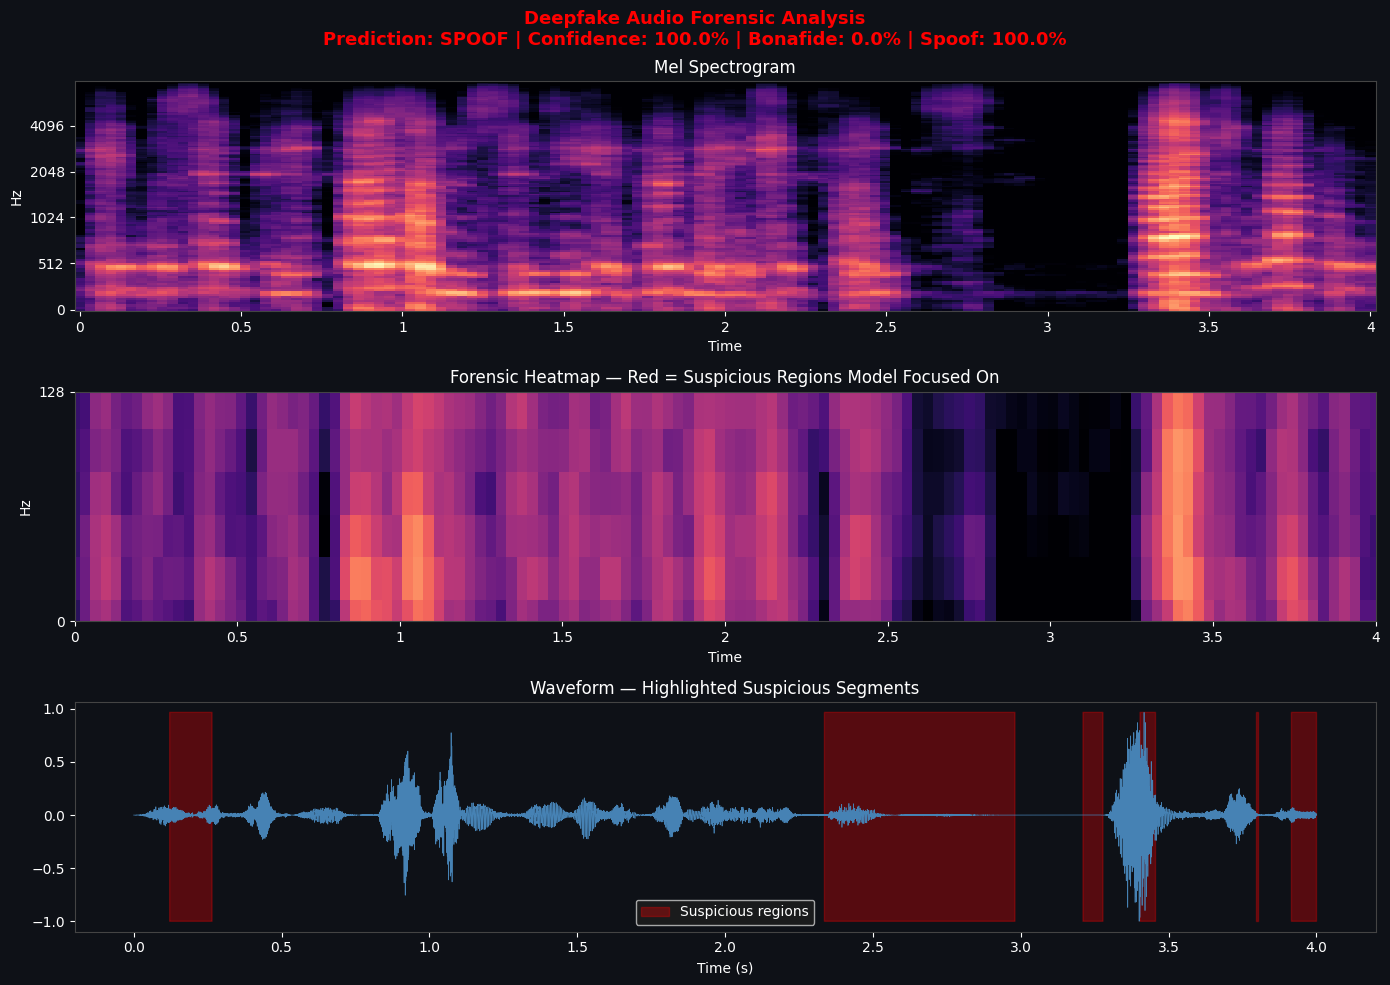

Saved to forensic_analysis.png


In [ ]:
from scipy.ndimage import zoom, gaussian_filter
from scipy.ndimage import uniform_filter1d
import librosa.display

def visualize_explanation(audio_path):
    audio, cam, pred_class, confidence, probs = predict_with_explanation(audio_path)

    label_name = "SPOOF" if pred_class == 1 else "BONAFIDE"
    color = "red" if pred_class == 1 else "green"
    sr = 16000

    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Fix 1: smooth CAM before resizing — removes blockiness
    cam_smooth = gaussian_filter(cam, sigma=3)
    cam_resized = zoom(cam_smooth, mel_db.shape[1] / len(cam_smooth))
    cam_2d = np.tile(cam_resized, (mel_db.shape[0], 1))

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.patch.set_facecolor('#0e1117')
    for ax in axes:
        ax.set_facecolor('#0e1117')
        ax.tick_params(colors='white')
        ax.xaxis.label.set_color('white')
        ax.yaxis.label.set_color('white')
        ax.title.set_color('white')
        for spine in ax.spines.values():
            spine.set_edgecolor('#444')

    fig.suptitle(
        f"Deepfake Audio Forensic Analysis\nPrediction: {label_name} | "
        f"Confidence: {confidence:.1%} | "
        f"Bonafide: {probs[0][0].item():.1%} | Spoof: {probs[0][1].item():.1%}",
        fontsize=13, fontweight='bold', color=color
    )

    # Plot 1: Mel Spectrogram
    axes[0].set_title("Mel Spectrogram")
    librosa.display.specshow(mel_db, sr=sr, x_axis='time',
                              y_axis='mel', ax=axes[0], cmap='magma')

    # Plot 2: Smooth heatmap overlay
    axes[1].set_title("Forensic Heatmap — Red = Suspicious Regions Model Focused On")
    librosa.display.specshow(mel_db, sr=sr, x_axis='time',
                              y_axis='mel', ax=axes[1], cmap='magma')
    axes[1].imshow(
        cam_2d, aspect='auto', origin='lower',
        extent=[0, len(audio)/sr, 0, mel_db.shape[0]],
        cmap='Reds', alpha=0.6
    )

    # Plot 3: Fix 2 — smooth waveform highlighting, no striping
    axes[2].set_title("Waveform — Highlighted Suspicious Segments")
    time_axis = np.linspace(0, len(audio)/sr, len(audio))
    axes[2].plot(time_axis, audio, color='steelblue', linewidth=0.5)

    cam_on_audio = zoom(cam_smooth, len(audio) / len(cam_smooth))
    # 100ms smoothing window — removes the striping artifact
    cam_smoothed = uniform_filter1d(cam_on_audio, size=sr//10)
    threshold = np.percentile(cam_smoothed, 75)
    suspicious = cam_smoothed > threshold
    axes[2].fill_between(time_axis, audio.min(), audio.max(),
                          where=suspicious, color='red', alpha=0.3,
                          label='Suspicious regions')
    axes[2].set_xlabel("Time (s)")
    axes[2].legend(facecolor='#1e1e1e', labelcolor='white')

    plt.tight_layout()
    plt.savefig("forensic_analysis.png", dpi=150,
                bbox_inches='tight', facecolor='#0e1117')
    plt.show()
    print("Saved to forensic_analysis.png")

# Run it
visualize_explanation(f"{test_path}/spoof/E_0002014899.flac")

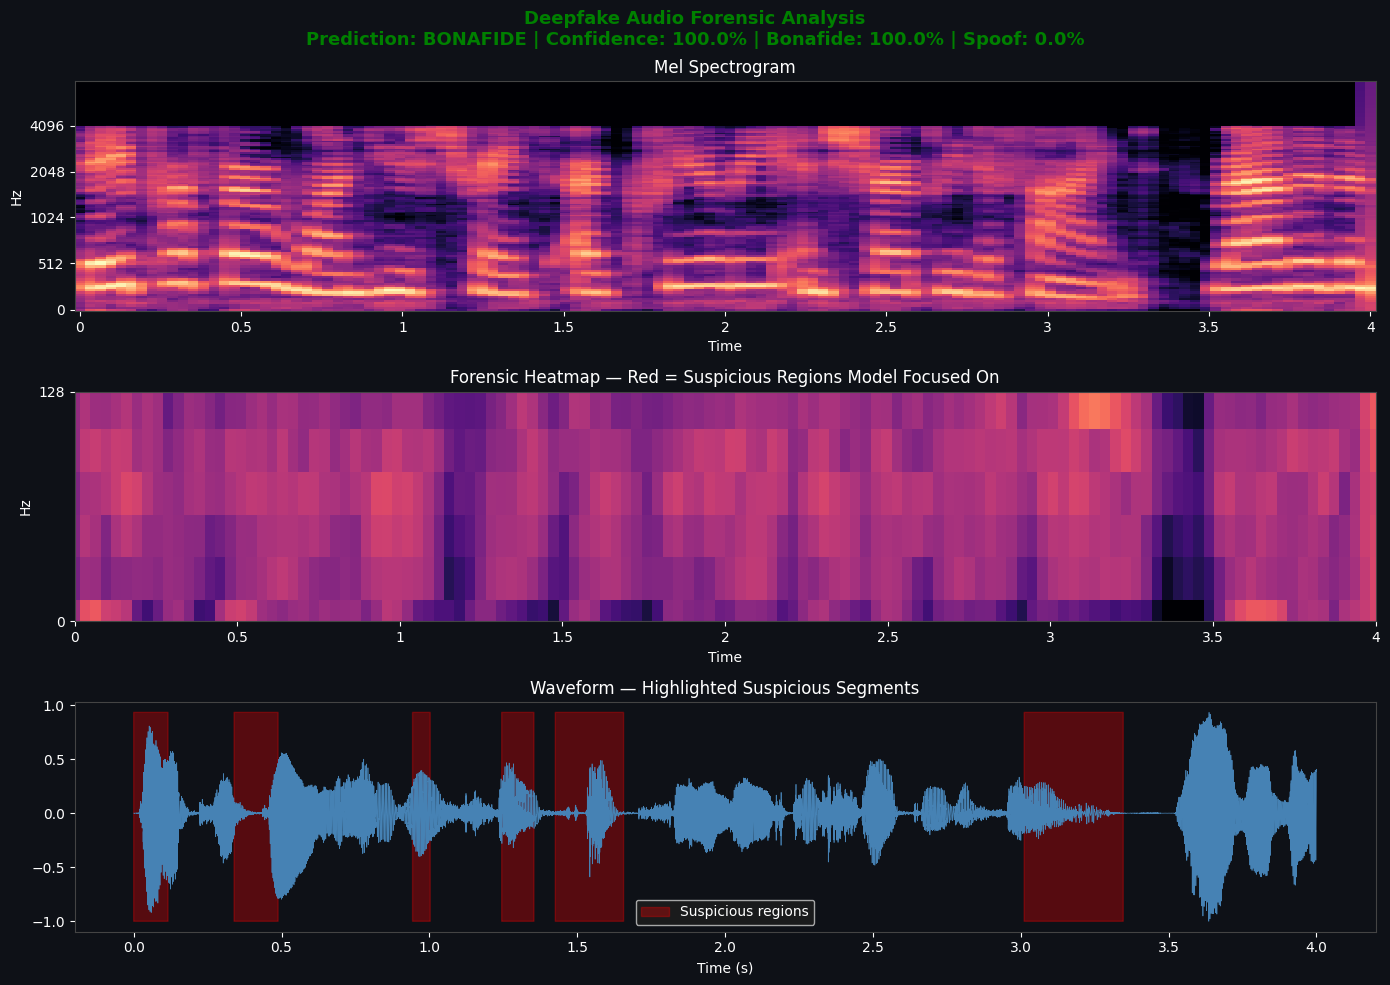

Saved to forensic_analysis.png


In [ ]:
visualize_explanation(f"{test_path}/bonafide/E_0002014823.flac")

Found 8 misclassified spoof files
File: E_0002151927.flac, Conf: 100.0%, Spoof prob: 0.0%


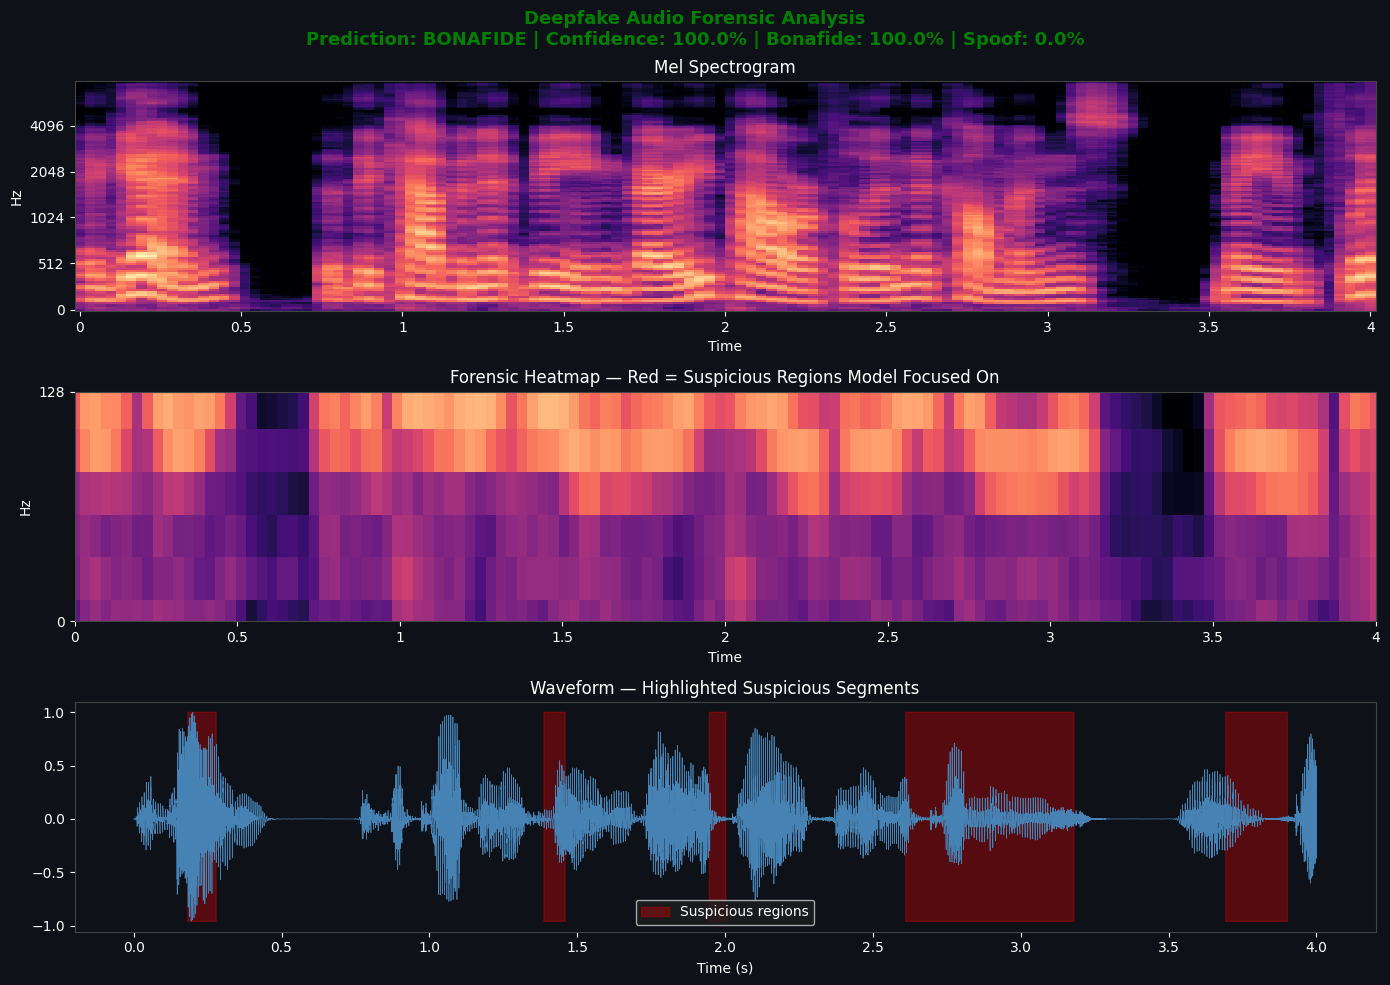

Saved to forensic_analysis.png
File: E_0002232538.flac, Conf: 100.0%, Spoof prob: 0.0%


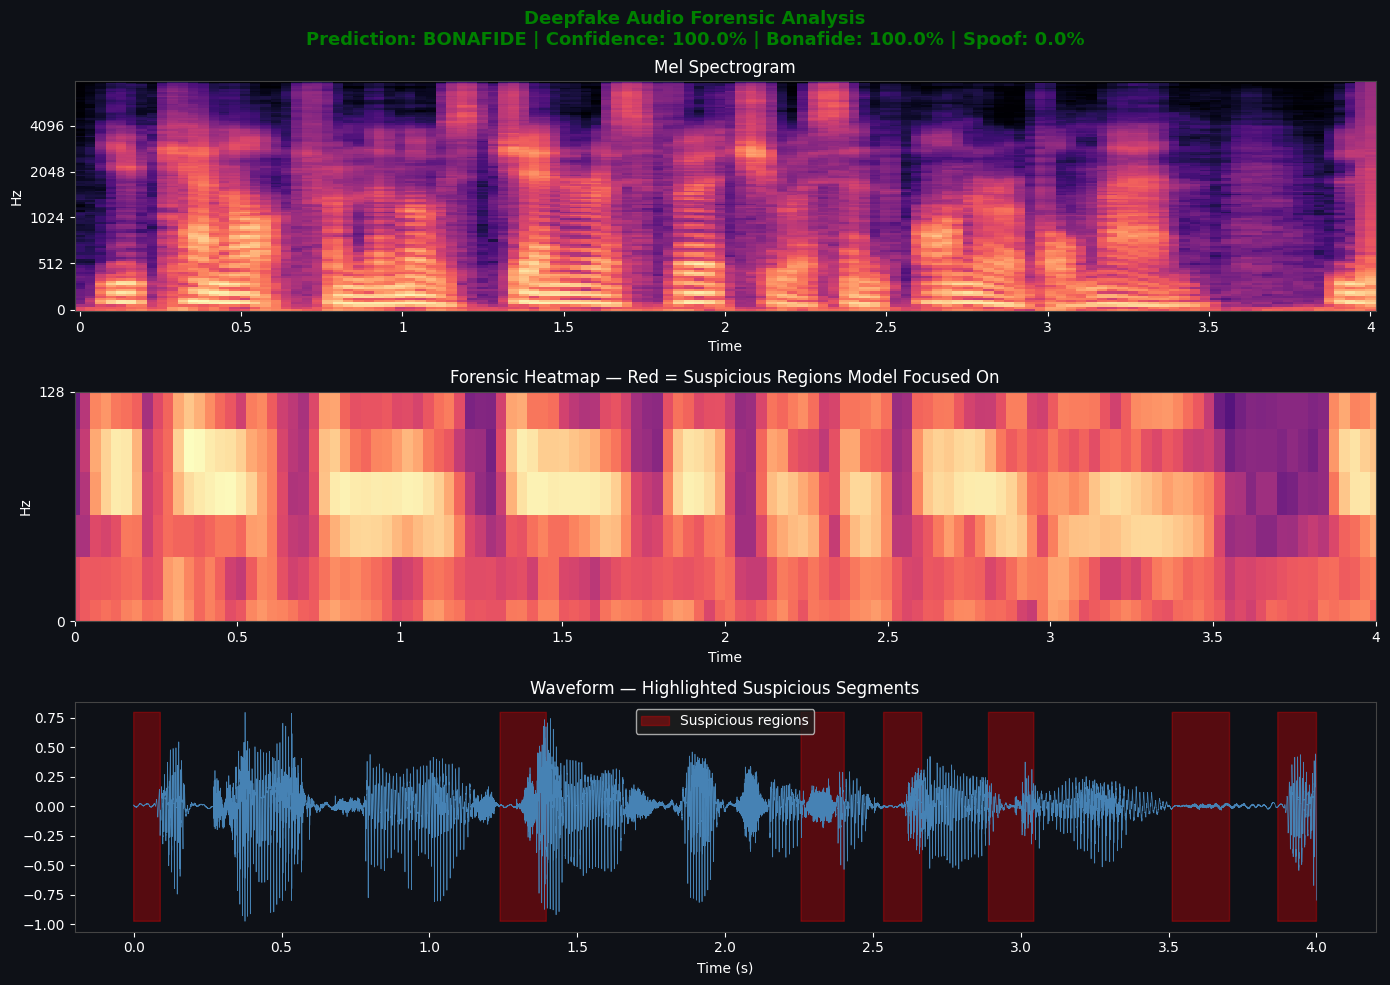

Saved to forensic_analysis.png


In [ ]:
# Find actual misclassified spoof files
misclassified = []
test_spoof = list(Path(test_path + "/spoof").glob("*.flac"))

for f in random.sample(test_spoof, 100):
    _, _, pred, conf, probs = predict_with_explanation(str(f))
    if pred == 0:  # predicted bonafide but actually spoof
        misclassified.append((str(f), conf,
                               probs[0][1].item()))

# Sort by confidence — most confident wrong predictions first
misclassified.sort(key=lambda x: x[1], reverse=True)
print(f"Found {len(misclassified)} misclassified spoof files")

# Visualize top 2
for fpath, conf, spoof_prob in misclassified[:2]:
    print(f"File: {Path(fpath).name}, "
          f"Conf: {conf:.1%}, Spoof prob: {spoof_prob:.1%}")
    visualize_explanation(fpath)

In [ ]:
def plot_layer_importance(model, input_values):
    layer_scores = []
    for i, layer in enumerate(model.wavlm.encoder.layers):
        acts = []
        def hook(m, inp, out):
            acts.append(out[0].detach().abs().mean().item())
        h = layer.register_forward_hook(hook)
        with torch.no_grad():
            model(input_values)
        h.remove()
        layer_scores.append(acts[0] if acts else 0)

    plt.figure(figsize=(10, 3), facecolor='#0e1117')
    ax = plt.gca()
    ax.set_facecolor('#0e1117')
    bars = ax.bar(range(len(layer_scores)), layer_scores,
                   color=['red' if i >= 9 else 'steelblue'
                          for i in range(len(layer_scores))])
    ax.set_xlabel("Transformer Layer", color='white')
    ax.set_ylabel("Mean Activation", color='white')
    ax.set_title("WavLM Layer Contributions to Deepfake Detection\n"
                  "(Red = fine-tuned layers)", color='white')
    ax.tick_params(colors='white')
    plt.tight_layout()
    plt.savefig("layer_importance.png", dpi=150, bbox_inches='tight',
                facecolor='#0e1117')
    plt.show()

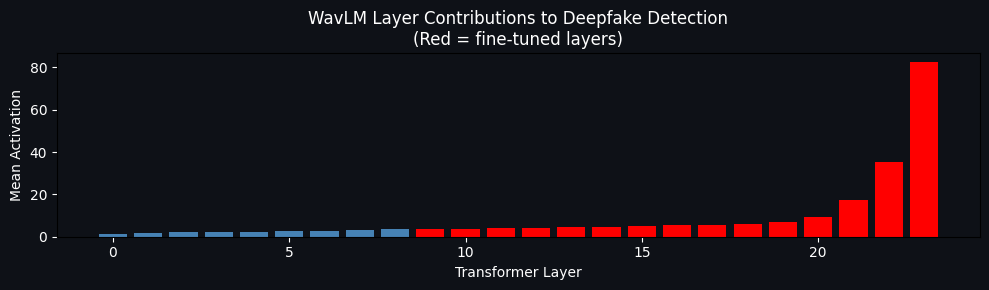

In [ ]:
# Get a sample input to run layer importance
sample_file = f"{test_path}/spoof/E_0002014899.flac"
audio, _ = librosa.load(sample_file, sr=16000, duration=4.0)
target_length = int(16000 * 4.0)
audio = np.pad(audio, (0, max(0, target_length - len(audio))))[:target_length]

inputs = feature_extractor(audio, sampling_rate=16000,
                            return_tensors="pt", padding=True)
input_values = inputs.input_values

# Now call it
plot_layer_importance(model, input_values)

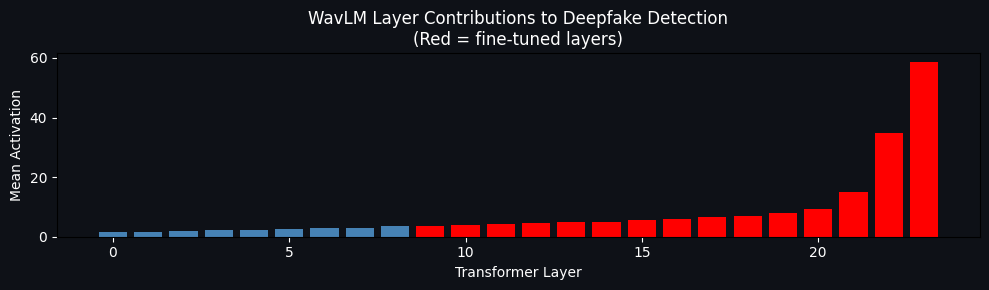

In [ ]:
# Get a sample input to run layer importance
sample_file = f"{test_path}/bonafide/E_0002014823.flac"
audio, _ = librosa.load(sample_file, sr=16000, duration=4.0)
target_length = int(16000 * 4.0)
audio = np.pad(audio, (0, max(0, target_length - len(audio))))[:target_length]

inputs = feature_extractor(audio, sampling_rate=16000,
                            return_tensors="pt", padding=True)
input_values = inputs.input_values

# Now call it
plot_layer_importance(model, input_values)